In [1]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# GPU 설정 확인
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("GPU Enabled")
    except RuntimeError as e:
        print(e)

# Import or install Sionna
try:

    import sionna.rt
except ImportError as e:
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

# Sionna RT의 주요 모듈 임포트
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera, RadioMapSolver, PathSolver
from sionna.rt.utils import r_hat, subcarrier_frequencies
from sionna.rt import scene as share_scene

2025-12-08 22:19:00.298214: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765228740.306745 1666917 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765228740.309441 1666917 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-08 22:19:00.318933: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPU Enabled


In [2]:
# IEEE 802.11 OFDM 파라미터
carrier_frequency = 5e9  
ch_bandwidth = 20e6        # 20 MHz (Hz 단위)
v = 2                        # 2m/s
n_fft = 64                 # FFT 크기
cp_length = 16             # CP 길이 (샘플 수, 0.8us at 20MHz)
symbol_duration = 4e-6     # OFDM 심볼 길이 (초)
n_data = 48                # 데이터 서브캐리어 개수
n_pilot = 4                # 파일럿 서브캐리어 개수

In [3]:
# Sionna RT 내장 샘플 환경 사용
from sionna.rt import scene as sample_scene

# 예시 1: 작은 사무실 환경
scene = load_scene("/home/ccs-lab/yura.min/apartment/apartment.xml")

# 송신기(기지국) 안테나 배열 (1x1, 무지향성)
scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization="cross")

# 수신기(단말) 안테나 배열 (1x1, 무지향성)
scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization="cross")

# 송신기 생성 및 추가
tx = Transmitter(name="tx",
                 position=[-1.7, 1.7, 2.0],
                 look_at=[0, 0, 0],
                 display_radius=0.1)
scene.add(tx)
tx.array = scene.tx_array  # ← 이거 추가!
# 수신기 생성 및 추가 (시작 위치, Random Waypoint Model로 이후 이동)
rx = Receiver(name="rx",
              position=[-2.1, 5.8, 1.0],
              display_radius=0.1)
scene.add(rx)

tx.look_at(rx)  # 송신기가 수신기를 바라봄

# 3D 시각화용 카메라 설정

bird_cam = Camera(position=[0, 3, 15], look_at=[-3, 3, 0]) # 위에서 본 것


# IEEE 802.11 파라미터를 3D scene에 적용
scene.frequency = carrier_frequency
scene.bandwidth = ch_bandwidth



2025-12-08 22:19:04 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).


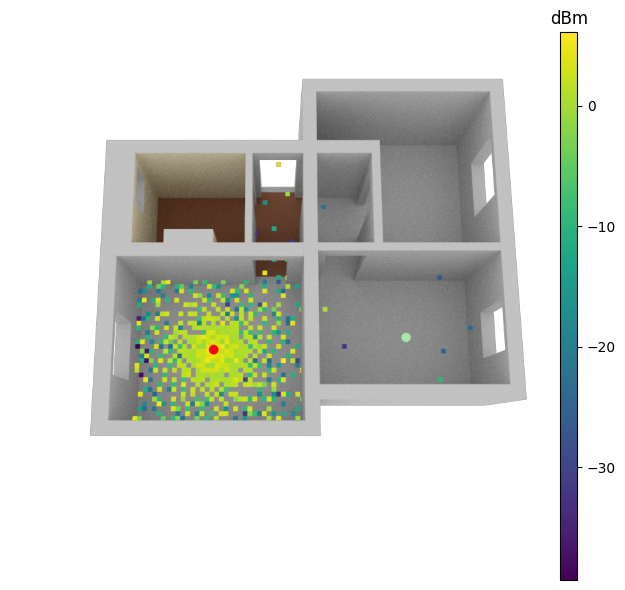

In [4]:
from sionna.rt import RadioMapSolver   # 꼭 추가!



max_depth = 4
cell_size = (0.1, 0.1)
samples_per_tx = 1000
resolution = (400, 400)

rm_solver = RadioMapSolver()
rm = rm_solver(scene,
               max_depth=max_depth,
               cell_size=cell_size,
               samples_per_tx=samples_per_tx)

output = scene.render(
    camera=bird_cam,
    radio_map=rm,
                  # radio_map과 경로를 동시에
    resolution=(800, 800),
    rm_metric="rss",
    rm_show_color_bar=True,

)

Rendering at step 411, Rx position: [-1.5035552  3.0340402  1.       ]
Rendering at step 521, Rx position: [-1.5124744  3.0395427  1.       ]
Rendering at step 660, Rx position: [-1.7445897  2.886551   1.       ]
Rendering at step 737, Rx position: [-1.8731716  2.8018     1.       ]
Rendering at step 740, Rx position: [-1.8781812  2.7984982  1.       ]


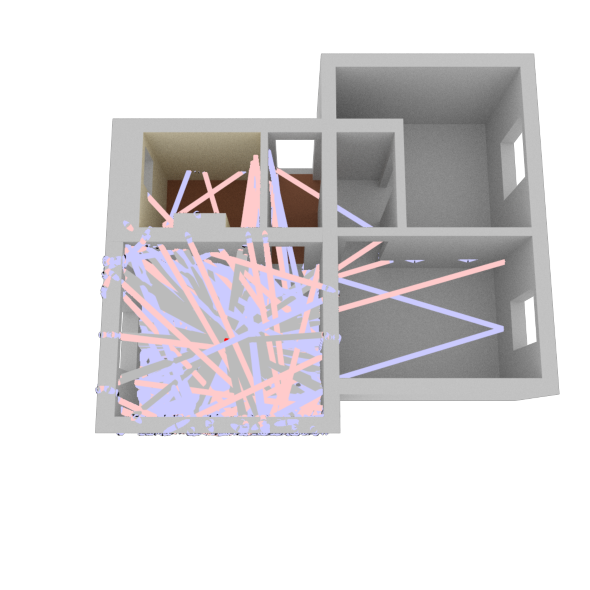

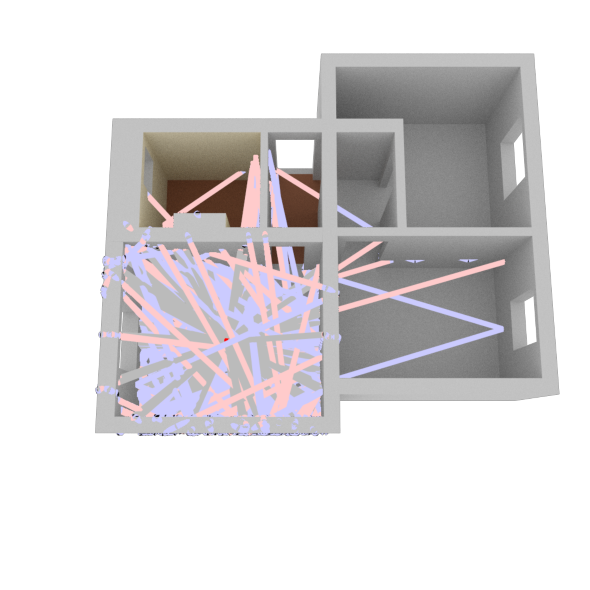

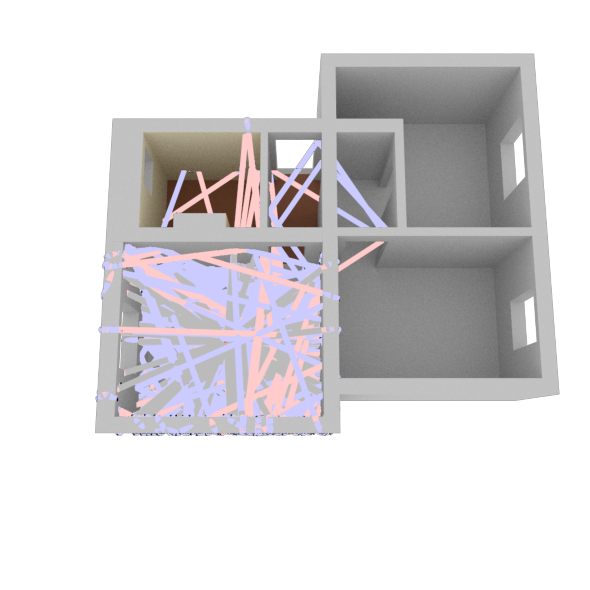

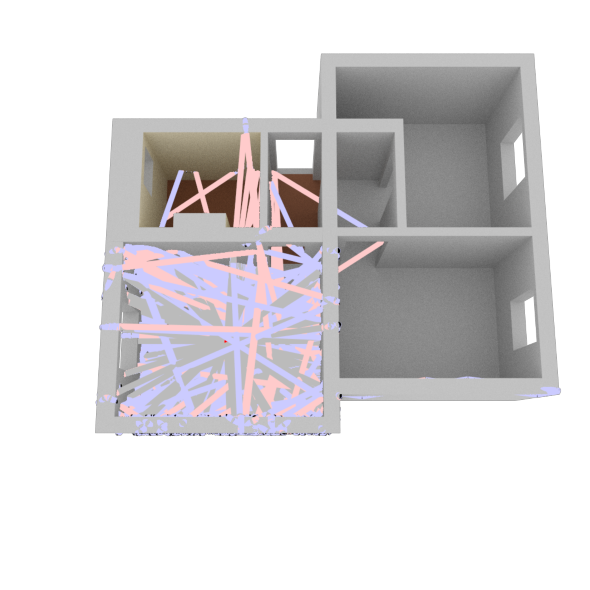

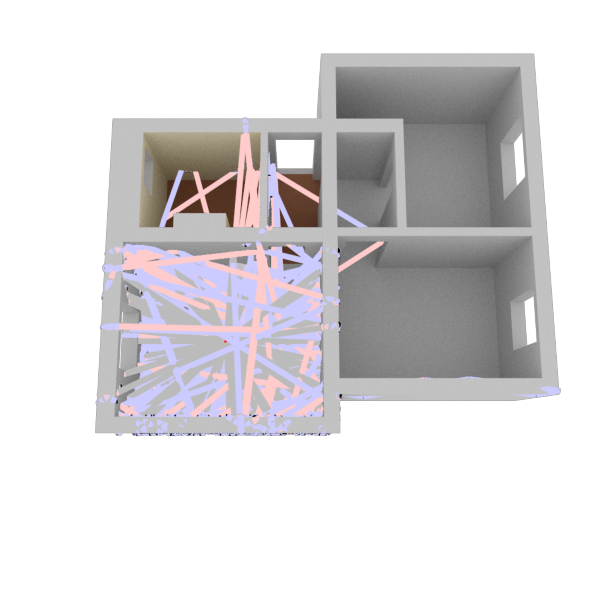

In [6]:
# Random Waypoint 생성 (방 내부로 제한)

def generate_random_waypoint_trajectory(
    area_bounds=[[-5, -0.5], [1, 7]],
    height=1.0,
    duration=1.0,
    dt=0.001,  # 시간 간격 살짝 여유
    threshold=1  # 목표 도달 판정 거리 크게
):
    num_steps = int(duration / dt)
    positions = []
    

# 초기 위치를 area_bounds 내에서 랜덤으로 설정
    x = np.random.uniform(area_bounds[0][0], area_bounds[0][1])
    y = np.random.uniform(area_bounds[1][0], area_bounds[1][1])
    pos = np.array([x, y])

    goal = None
    
    for _ in range(num_steps):
        if goal is None or np.linalg.norm(goal - pos) < threshold:
            # 새 목표 지점 샘플링 (이게 진짜 핵심!)
            x = np.random.uniform(area_bounds[0][0], area_bounds[0][1])
            y = np.random.uniform(area_bounds[1][0], area_bounds[1][1])
            goal = np.array([x, y])
            direction = goal - pos
            direction /= np.linalg.norm(direction)

        pos = pos + v * dt * direction
        positions.append([pos[0], pos[1], height])

    return np.array(positions, dtype=np.float32)

channel_taps_history = []
positions = generate_random_waypoint_trajectory()


# Velocity 추출 (finite difference)
dt=0.001
velocities = (positions[1:] - positions[:-1]) / dt
velocities = np.vstack([velocities, velocities[-1]])  # 마지막 스텝 보정

path_solver = PathSolver()

# 전체 time-evolution CIR 시퀀스 수집
time_cir_sequence = []
sampling_frequency = 1000  # 1kHz
num_time_steps = 1000  # time-evolution 길이

# 시각화 샘플링: 1000개 중 10개만 렌더링
np.random.seed(42)
render_indices = np.random.choice(len(positions), size=5, replace=False)


channels = []

for i, pos in enumerate(positions):
    try:
        scene.remove("rx")
    except KeyError:
        pass

    rx = Receiver(name="rx", 
                  position=pos.tolist(), 
                  display_radius=0.2,
                  velocity=velocities[i].tolist())
    scene.add(rx)
    tx.look_at(rx)

    paths = path_solver(scene=scene,
                        max_depth=20,  # 속도 최적화
                        max_num_paths_per_src=1000000,
                        los=True,
                        specular_reflection=True,
                        diffuse_reflection=True,
                        refraction=True,
                        synthetic_array=False,
                        seed=42)

    if i in render_indices:
        print(f"Rendering at step {i}, Rx position: {pos}")
        scene.render(camera=bird_cam, paths=paths, clip_at=20, resolution=(1024, 1024))


    cir_list = paths.cir()
    if len(cir_list[0]) == 0:
        ch = tf.zeros([1, 1, 1], dtype=tf.complex64)
    else:
        cir = cir_list[0][0]
        ch = cir

    channels.append(ch)

    # 3. CIR을 Taps로 변환 (스냅샷 저장)
    taps = paths.taps(bandwidth=ch_bandwidth, 
                      l_min=0, l_max=64,      # 0번부터 64번 탭까지만 저장
                      normalize=True, 
                      out_type="numpy")
    # 데이터 저장 (가장 강한 안테나 링크 하나만: index [0,0,0,0,0,:])
    channel_taps_history.append(taps[0,0,0,0,0,:]) # index [0,0,0,0,0,:]는 (Batch, Rx, RxAnt, Tx, TxAnt) 차원을 제거하고
    # 순수한 '탭(Delay Tap)' 데이터만 남기는 것입니다.

    # time-evolution CIR 수집
    a_mob, _ = paths.cir(sampling_frequency=1000, num_time_steps=1000, out_type="numpy")
    time_cir_sequence.append(a_mob[0,0,0,0,0,:])


channel_matrix = np.array(channel_taps_history)    
time_cir_sequence = np.stack(time_cir_sequence, axis=0)  # shape: [trajectory_steps, num_time_steps]

In [7]:
# positions: [ [x1,y1,z1], [x2,y2,z2], [x3,y3,z3] ... ]

# 1. (다음 위치) - (현재 위치) = 이동 거리 벡터
delta_pos = positions[1:] - positions[:-1] 

# 2. 이동 거리 / 시간 간격 = 속도 벡터
velocities = delta_pos / dt

print(velocities)

[[ 0.82159036 -1.8234252   0.        ]
 [ 0.82159036 -1.8234252   0.        ]
 [ 0.82159036 -1.8236636   0.        ]
 ...
 [-1.6698836  -1.1007786   0.        ]
 [-1.6698836  -1.1005402   0.        ]
 [-1.6698836  -1.1007786   0.        ]]


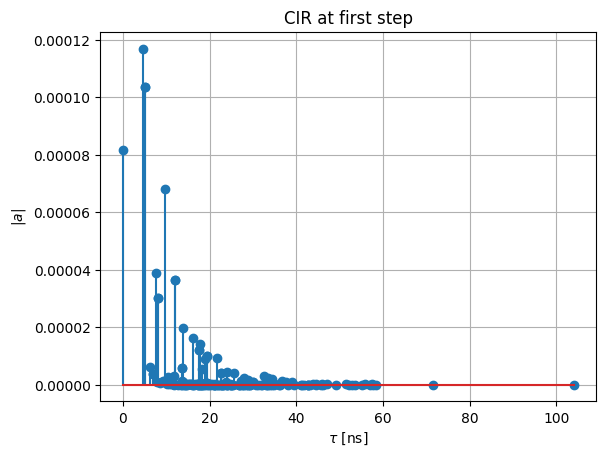

In [8]:
# CIR 시퀀스 수집 전용 "무선 채널의 충격 응답(CIR, Channel Impulse Response)을 계산하고, 그중 첫 번째 순간의 '메아리(Multipath)'들을 시각화하는 코드입니다. 
# 쉽게 비유하자면, **"방 안에서 손뼉을 딱! 쳤을 때, 소리가 직접 들리는 것과 벽에 튕겨서 늦게 들리는 메아리들이 각각 언제, 얼마나 크게 들리는지 그래프로 그리는 것입니다.

a_np_list = []
tau_np_list = []
a_np, tau_np = paths.cir(normalize_delays=True, out_type="numpy")
a_np_list.append(a_np)
tau_np_list.append(tau_np)

# 예: 첫번째 스텝의 CIR 시각화
t = tau_np_list[0][0,0,0,0,:]/1e-9
a_abs = np.abs(a_np_list[0])[0,0,0,0,:,0]

plt.figure()
plt.title("CIR at first step")
plt.stem(t, a_abs)
plt.xlabel(r"$\tau$ [ns]")
plt.ylabel(r"$|a|$")
plt.grid(True)
plt.show()

#이 코드를 돌려서 알 수 있는 것:
#전파 환경이 얼마나 복잡한가? (막대가 1개면 깔끔한 환경, 막대가 수십 개면 반사가 심한 복잡한 방)

#지연 확산(Delay Spread): 마지막 메아리가 얼마나 늦게 도착하는가? (이게 길어지면 통신 속도를 높이기 어렵습니다.)

##신호 세기: 수신기가 현재 위치에서 신호를 얼마나 강하게 받고 있는가?

Shape of h_freq:  (1, 2, 1, 2, 1, 64)


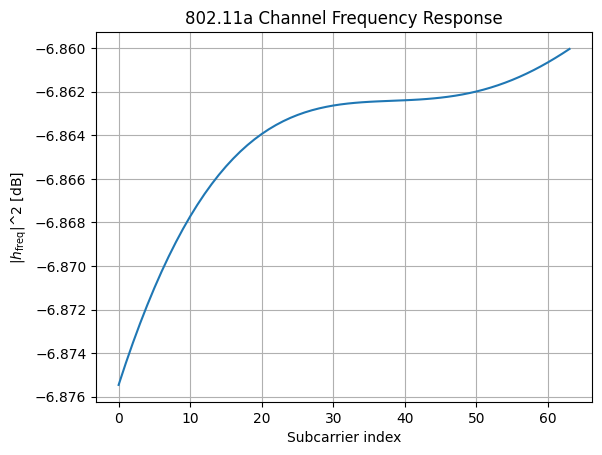

In [9]:
#CIR을 푸리에 변환, 각 주파수 별로 신호가 얼마나 세게, 혹은 약하게 도달하는지

# OFDM system parameters for 802.11a
num_subcarriers = 64
subcarrier_spacing = 312.5e3  # 312.5 kHz

# Compute frequencies of subcarriers relative to carrier frequency
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

# Compute channel frequency response from paths
h_freq = paths.cfr(frequencies=frequencies,
                   normalize=False,
                   normalize_delays=True,
                   out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_time_steps, num_subcarriers]
print("Shape of h_freq: ", h_freq.shape)

# Plot CFR
plt.figure()
plt.plot(np.log10(np.abs(h_freq)[0,0,0,0,0,:] ** 2));
plt.xlabel("Subcarrier index")
plt.ylabel(r"|$h_\text{freq}$|^2 [dB]")
plt.title("802.11a Channel Frequency Response")
plt.grid(True)
plt.show()


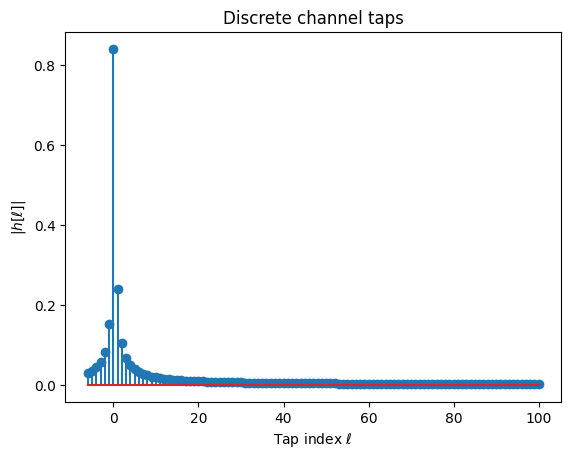

In [10]:
#이 코드는 앞서 구했던 **물리적인 전파 경로(Analog/Continuous)**를 디지털 통신 시스템이 처리할 수 있는 이산적인 디지털 필터(Digital/Discrete Taps) 형태로 변환하는 과정입니다.
#쉽게 말해, "현실 세계의 메아리(CIR)를 컴퓨터(DSP)가 이해할 수 있는 숫자의 배열로 '샘플링'해서 옮겨 담는 작업"입니다.

(frequencies[-1] - frequencies[0]) / 1e6 #대역폭 계산. 대역폭이 넓을수록 시간 축에서 더 촘촘하게(미세하게) 채널을 쪼개서 볼 수 있습니다.

taps = paths.taps(bandwidth=ch_bandwidth,
                      l_min=-6, l_max=100, #채널을 최대 100샘플 길이까지 보겠다
                      normalize=True,
                      normalize_delays=True,
                      out_type="numpy")

# 시퀀스 시각화 (PDP heatmap)
plt.figure()
plt.stem(np.arange(-6, 101), np.abs(taps)[0,0,0,0,0]);
plt.xlabel(r"Tap index $\ell$");
plt.ylabel(r"|$h[\ell]|$");
plt.title("Discrete channel taps");
plt.show()

#관찰: **0번 인덱스(Tap 0)**의 값이 약 0.65로 가장 크고, 나머지 탭들은 상대적으로 매우 작습니다.

#분석:이는 전파 에너지의 90% 이상이 **가장 먼저 도착하는 샘플(LoS 경로)**에 집중되어 있다는 뜻입니다.
#통신 이론에서는 이를 "Frequency Flat Fading(주파수 비선택적 페이딩)" 환경이라고 부릅니다.
#의미: 수신기는 복잡한 신호 처리를 할 필요 없이, 0번 탭의 신호만 잘 잡아내면 원본 데이터를 거의 완벽하게 복구할 수 있습니다.


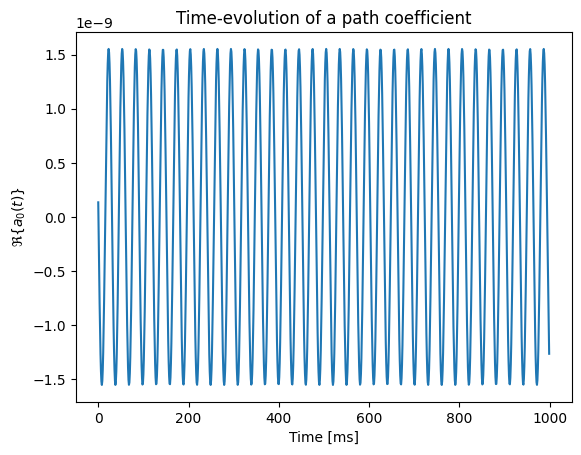

In [11]:
#로봇이 움직임에 따라 발생하는 도플러 효과로 인해 신호가 시간 흐름에 따라 어떻게 출렁이는지(Fading)

sampling_frequency = 1000  # 1kHz

# 시각화
plt.figure()
plt.plot(np.arange(num_time_steps)/sampling_frequency*1000,
         a_mob[0,0,0,0,0].real);
plt.xlabel("Time [ms]");
plt.ylabel(r"$\Re\{a_0(t) \}$");
plt.title("Time-evolution of a path coefficient");

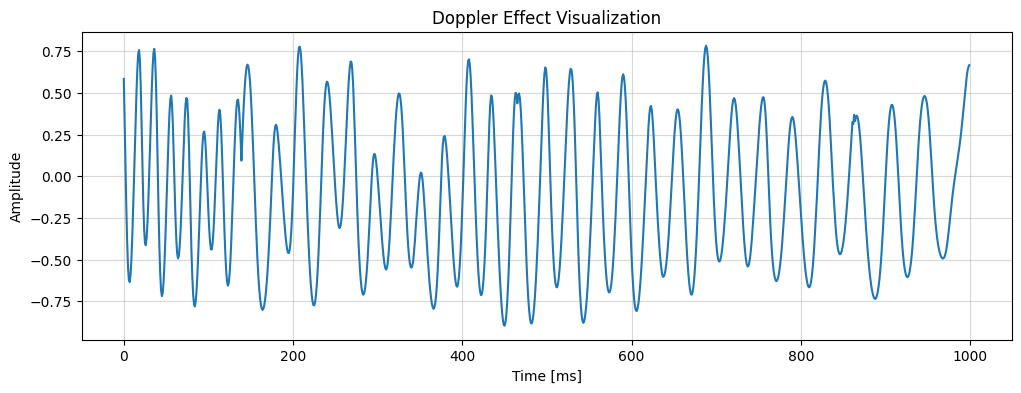

In [12]:
# [Cell 3] 도플러 및 채널 히트맵 시각화

# 2. 도플러 진동 확인 (LoS Path 위상 변화)
# 0번 탭(주로 LoS)의 실수부(Real part)를 그려서 진동 확인
los_signal = channel_matrix[:, 0] 

plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(positions))*dt*1000, np.real(los_signal))
plt.title("Doppler Effect Visualization")
plt.xlabel("Time [ms]")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.5)
#plt.xlim(0, 200) # 앞부분 200ms만 확대해서 파형 자세히 보기 (필요시 제거)
plt.show()

Shape of b_mob:  (1, 2, 1, 2, 1000, 64)


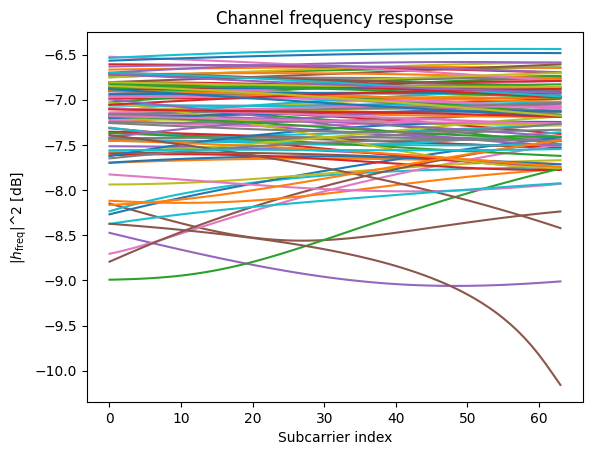

In [13]:
b_mob = paths.cfr(sampling_frequency=sampling_frequency,
                         num_time_steps=num_time_steps,
                         frequencies=frequencies,
                         out_type="numpy")
print("Shape of b_mob: ", b_mob.shape)

# Plot absolute value
plt.figure()
for idx in range(0, num_time_steps, 10):
    plt.plot(np.log10(np.abs(b_mob)[0,0,0,0,idx,:] ** 2));
plt.xlabel("Subcarrier index");
plt.ylabel(r"|$h_\text{freq}$|^2 [dB]");
plt.title("Channel frequency response");

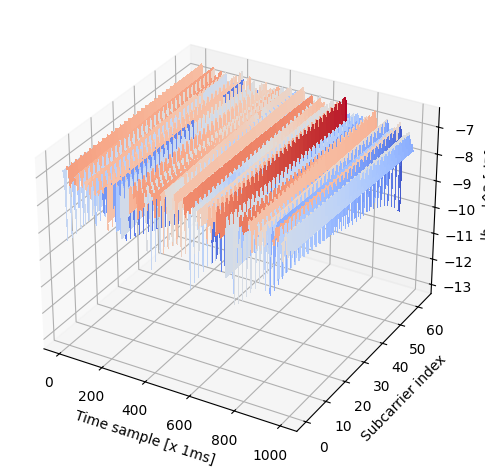

In [14]:
X = np.arange(0, b_mob.shape[4])
Y = np.arange(0, b_mob.shape[5])
X, Y = np.meshgrid(X, Y)
X.shape

Z = np.zeros((b_mob.shape[5], b_mob.shape[4]))
Z.shape

for idx in range(0, num_time_steps):
    Z[:,idx] = np.log10(np.abs(b_mob)[0,0,0,0,idx,:] ** 2)
    #Z[:,idx] = np.angle(b_mob)[0,0,0,0,idx,:]
    
    # Plot the surface.
from matplotlib import cm
from matplotlib.ticker import LinearLocator


fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

# Customize the z axis.
#ax.set_zlim(-1.01, 1.01)
#ax.zaxis.set_major_locator(LinearLocator(10))
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter('{x:.0f}')

# Add a color bar which maps values to colors.
#fig.colorbar(surf, shrink=0.2, aspect=5)
ax.set_xlabel("Time sample [x 1ms]");
ax.set_ylabel("Subcarrier index");
ax.set_zlabel(r"|$h_\text{freq}$|^2 [dB]");
plt.tight_layout()
plt.show()

In [15]:
import scipy.io
import numpy as np

# ---------------------------------------------------------
# 1. CFR 정리: b_mob -> CFR (Time, Subcarrier)
# ---------------------------------------------------------
# b_mob: [B, R, TB, Tx, T, K]
B, R, TB, Tx, T, K = b_mob.shape
print("b_mob shape:", b_mob.shape)

# 한 링크(예: B=0, R=0, TB=0, Tx=0)만 선택해서 [T, K]로 사용
# 필요하면 R, Tx 인덱스를 바꿔서 다른 안테나 조합을 고를 수 있음
h_cfr_clean = b_mob[0, 0, 0, 0, :, :]   # (T, K)

CFR = h_cfr_clean.astype(np.complex64, copy=False)
print("CFR shape:", CFR.shape, "(Time x Subcarriers)")


# ---------------------------------------------------------
# 2. CIR 정리: paths.cir() -> CIR_amp, CIR_delay
# ---------------------------------------------------------
# sampling_frequency, num_time_steps 는 앞 셀에서 이미 정의됨
a_cir, tau_cir = paths.cir(
    sampling_frequency=sampling_frequency,
    num_time_steps=num_time_steps,
    normalize_delays=True
)

# TensorFlow 텐서일 수도 있으니 numpy로 변환
if hasattr(a_cir, "numpy"):
    a_cir = a_cir.numpy()
if hasattr(tau_cir, "numpy"):
    tau_cir = tau_cir.numpy()

# 불필요한 차원 제거
a_cir_clean = np.squeeze(a_cir)      # 보통 [Paths, Time] 또는 [Time, Paths] 중 하나
tau_cir_clean = np.squeeze(tau_cir)  # [Paths]

# 형태를 (Time, Paths)로 맞추기
if a_cir_clean.shape[0] != num_time_steps and a_cir_clean.shape[-1] == num_time_steps:
    a_cir_clean = a_cir_clean.T

CIR_amp = a_cir_clean
CIR_delay = tau_cir_clean

print("CIR_amp shape:", CIR_amp.shape, "(Time x Paths)")
print("CIR_delay shape:", CIR_delay.shape, "(Paths)")

# ---------------------------------------------------------
# 3. 축 정보 & 메타데이터
# ---------------------------------------------------------
# 시간 축: 초 단위
time_axis = np.arange(num_time_steps) / float(sampling_frequency)

# 주파수 축: subcarrier_frequencies()로 만든 frequencies 변수 재사용
# (Sionna 텐서일 수 있으니 numpy로 변환)
freq_axis = frequencies.numpy() if hasattr(frequencies, "numpy") else frequencies

num_subcarriers = K
subcarrier_spacing = ch_bandwidth / num_subcarriers  # 20MHz / 64 = 312.5kHz (이론상)

# ---------------------------------------------------------
# 4. .mat로 저장할 딕셔너리 구성
# ---------------------------------------------------------
mat_data = {
    # --- 핵심 데이터 ---
    "CFR": CFR,                # (Time, Subcarrier) 복소수 주파수 도메인 CSI
    "CIR_amp": CIR_amp,        # (Time, Paths) 복소수 임펄스 응답 계수
    "CIR_delay": CIR_delay,    # (Paths,) 지연 (초 또는 내부 단위)

    # --- 축 정보 ---
    "time_axis": time_axis,    # (Time,) 시간축 [s]
    "freq_axis": freq_axis,    # (Subcarrier,) 주파수축 [Hz]

    # --- 설정 값 ---
    "num_subcarriers": num_subcarriers,
    "subcarrier_spacing": subcarrier_spacing,
    "sampling_frequency": float(sampling_frequency),  # [Hz]

    # --- 이동 정보 (옵션) ---
    "positions": positions,    # (N, 3) Rx 궤적
    "velocities": velocities,  # (N, 3) Rx 속도
    "param_dt": dt,            # 시뮬레이션 시간 간격 [s]
    "param_fc": carrier_frequency,  # 중심 주파수 [Hz]
}

# ---------------------------------------------------------
# 5. 파일명 자동 생성 (기존 포맷 유지)
# ---------------------------------------------------------
freq_str = f"{carrier_frequency/1e9:.1f}GHz"   # 예: 5.0GHz
vel_str  = f"{v:.1f}m_s"                       # 예: 2.0m_s
bw_str   = f"{ch_bandwidth/1e6:.0f}MHz"        # 예: 20MHz
dt_str   = f"{dt*1000:.1f}ms"                  # 예: 1.0ms

filename = f"cfr_Fc={freq_str}_v={vel_str}_BW={bw_str}_dt={dt_str}_csi_dataset.mat"
print(f"📂 저장될 파일명: {filename}")

# ---------------------------------------------------------
# 6. .mat 파일 저장
# ---------------------------------------------------------
scipy.io.savemat(filename, mat_data, do_compression=True)
print("✅ 저장 완료!")


b_mob shape: (1, 2, 1, 2, 1000, 64)
CFR shape: (1000, 64) (Time x Subcarriers)
CIR_amp shape: (1000, 184, 2, 2, 2) (Time x Paths)
CIR_delay shape: (2, 2, 184) (Paths)
📂 저장될 파일명: cfr_Fc=5.0GHz_v=2.0m_s_BW=20MHz_dt=1.0ms_csi_dataset.mat
✅ 저장 완료!


📊 데이터 형태(Shape): (1000, 64)
⏱️ 시간 길이: 1.0 ms
📡 주파수 대역: 64개 부반송파


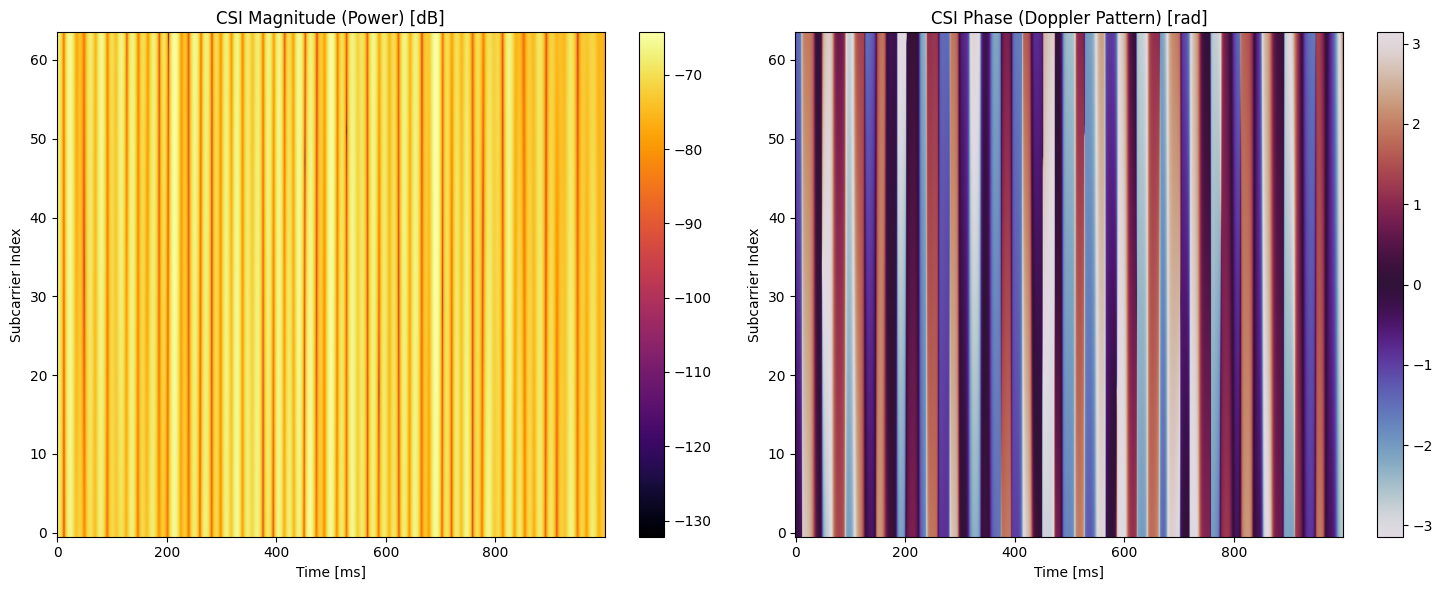

In [16]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

import os
import shutil

# 1. 파일 로드
data = scipy.io.loadmat(f"cfr_Fc={freq_str}_v={vel_str}_BW={bw_str}_dt={dt_str}_csi_dataset.mat")
csi = data['CFR']   # Shape 예상: (1000, 64, 1, 1)
t_ms = data['time_axis'][0]
f_hz = data['freq_axis'][0]

print(f"📊 데이터 형태(Shape): {csi.shape}")
print(f"⏱️ 시간 길이: {t_ms[-1] - t_ms[0]:.1f} ms")
print(f"📡 주파수 대역: {len(f_hz)}개 부반송파")

# 복소수 데이터 분리
csi_mag = np.abs(csi)   # 크기 (Amplitude)
csi_pha = np.angle(csi) # 위상 (Phase)

# 2. 시각화 (엑스레이 촬영)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# (왼쪽) 크기(Magnitude) - 전력이 얼마나 센가?
# 전치(.T)를 해서 시간(X축) vs 주파수(Y축)으로 봅니다.
im1 = ax[0].imshow(10*np.log10(csi_mag.T**2), aspect='auto', cmap='inferno', origin='lower')
ax[0].set_title("CSI Magnitude (Power) [dB]")
ax[0].set_xlabel("Time [ms]")
ax[0].set_ylabel("Subcarrier Index")
plt.colorbar(im1, ax=ax[0])

# (오른쪽) 위상(Phase) - 도플러가 보이는가? (가장 중요!)
im2 = ax[1].imshow(csi_pha.T, aspect='auto', cmap='twilight', origin='lower')
ax[1].set_title("CSI Phase (Doppler Pattern) [rad]")
ax[1].set_xlabel("Time [ms]")
ax[1].set_ylabel("Subcarrier Index")
plt.colorbar(im2, ax=ax[1])

plt.tight_layout()
plt.show()

로드된 원본 데이터 shape: (1000, 64)
전처리된 시계열 데이터 shape: (1000, 64)
생성된 학습용 데이터(X) shape: (990, 10, 64)
생성된 타깃 데이터(Y) shape: (990, 64)
Train set: (891, 10, 64), (891, 64)
Test set : (99, 10, 64), (99, 64)


I0000 00:00:1765229542.203871 1666917 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6145 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:2b:00.0, compute capability: 8.6


학습 시작...
Epoch 1/50


I0000 00:00:1765229543.520866 1677811 cuda_dnn.cc:529] Loaded cuDNN version 90101


28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1315 - val_loss: 0.0089
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0149 - val_loss: 0.0032
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0056 - val_loss: 0.0022
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0037 - val_loss: 0.0019
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0027 - val_loss: 0.0016
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0023 - val_loss: 0.0014
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0020 - val_loss: 0.0013
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0018 - val_loss: 0.0012
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0016 - val_loss: 0.0011
Epoch 10/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015 - val_loss: 0.0010
Epoch 11/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0014 - val_loss: 9.7700e-04
Epoch 12/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0013 - val_loss: 9.

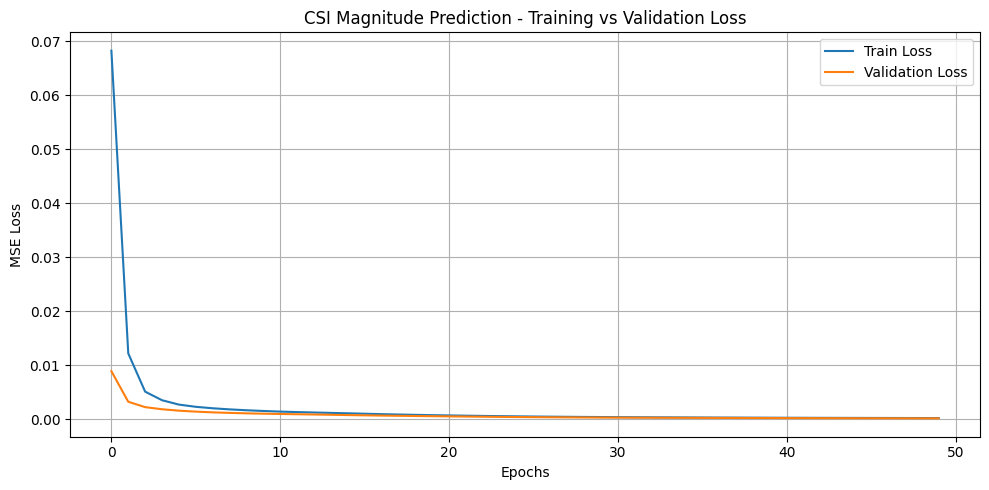

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


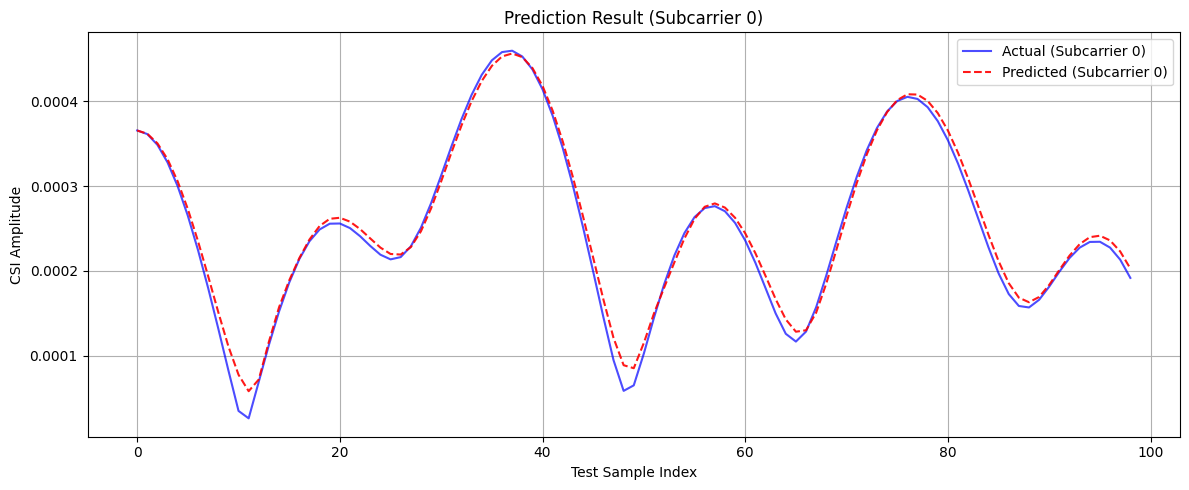

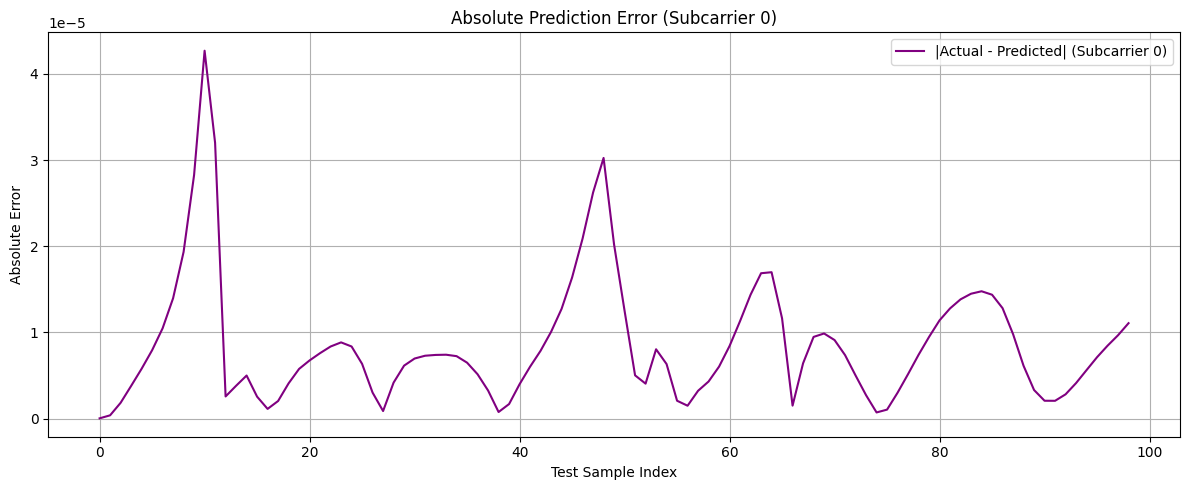

In [17]:
import scipy.io as sio
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input
import matplotlib.pyplot as plt
import os

# -----------------------------------------
# (선택) 재현성을 위해 시드 고정
# -----------------------------------------
np.random.seed(42)
tf.random.set_seed(42)

# -----------------------------------------
# 1) 데이터 로드 및 전처리
# -----------------------------------------
mat_path = f"cfr_Fc={freq_str}_v={vel_str}_BW={bw_str}_dt={dt_str}_csi_dataset.mat"

if not os.path.exists(mat_path):
    print(f"에러: 파일을 찾을 수 없습니다. 경로를 확인하세요: {mat_path}")
    # 파일이 없을 경우를 대비해 가상 데이터 생성 (실행 방지용)
    csi, labels = None, None
else:
    data = sio.loadmat(mat_path)
    
    # [수정 1] .mat 파일 내부 키 확인 및 로드
    # 사용자가 생성한 파일의 키는 'csi'입니다.
    if 'csi' in data:
        raw_data = data['csi']
    elif 'CFR' in data:
        raw_data = data['CFR']
    else:
        raise KeyError("파일 내에 'csi' 또는 'CFR' 키가 없습니다. 데이터 구조를 확인하세요.")

    print(f"로드된 원본 데이터 shape: {raw_data.shape}")

    # [수정 2] 복소수 -> 진폭 변환 및 차원 축소
    # 데이터 형태 예상: (Time=1000, Sub=64) (이미 2차원으로 저장됨)
    # 만약 복소수라면 절대값(Magnitude)을 취합니다.
    if np.iscomplexobj(raw_data):
        raw_amp = np.abs(raw_data)
    else:
        raw_amp = raw_data
        
    # 이미 (1000, 64) 형태라면 별도의 슬라이싱이 필요 없습니다.
    # 만약 차원이 더 많다면 (N, 1, 1, 64) 등을 (N, 64)로 펴줍니다.
    if raw_amp.ndim > 2:
        # (N, 1, 1, 1, 64) -> (N, 64) 
        time_series_data = raw_amp.reshape(raw_amp.shape[0], -1)
    else:
        time_series_data = raw_amp

    print("전처리된 시계열 데이터 shape:", time_series_data.shape) # (1000, 64)

    # [수정 3] 슬라이딩 윈도우(Sliding Window) 데이터셋 생성
    # 시계열 데이터를 LSTM 입력 형태 (N, T, F)로 변환
    lags = 10  # 과거 10개의 데이터를 보고
    F = time_series_data.shape[1] # 64개의 서브캐리어
    
    X_list = []
    Y_list = []
    
    # 데이터셋 생성 (1000개 데이터 사용)
    for i in range(len(time_series_data) - lags):
        X_list.append(time_series_data[i : i + lags]) # 입력: t ~ t+9
        Y_list.append(time_series_data[i + lags])     # 정답: t+10
        
    csi_X = np.array(X_list)    # data (N, T, F)
    labels_Y = np.array(Y_list) # labels (N, F)

    print("생성된 학습용 데이터(X) shape:", csi_X.shape)      # (990, 10, 64)
    print("생성된 타깃 데이터(Y) shape:", labels_Y.shape)     # (990, 64)

    # -----------------------------------------
    # 2) 스케일링 (0~1 범위로 정규화)
    # -----------------------------------------
    # csi_X: (N, T, F)
    N, T, F = csi_X.shape

    scaler = MinMaxScaler()

    # (N, T, F) -> (N*T, F) 로 펼쳐서 fit
    # 전체 데이터의 분포를 반영하기 위해 2D로 변환하여 스케일링
    csi_2d = csi_X.reshape(-1, F)
    scaler.fit(csi_2d)

    # 입력 X 스케일링 후 다시 (N, T, F)로 reshape
    scaled_csi = scaler.transform(csi_2d).reshape(N, T, F)

    # 타깃 Y도 같은 스케일러로 변환 (shape: (N, F))
    scaled_labels = scaler.transform(labels_Y)

    # -----------------------------------------
    # 3) Train / Test 분할 (90% / 10%)
    # -----------------------------------------
    split_percentage = 0.9
    split_point = int(N * split_percentage)

    X_train = scaled_csi[:split_point]
    Y_train = scaled_labels[:split_point]
    X_test  = scaled_csi[split_point:]
    Y_test  = scaled_labels[split_point:]

    print(f"Train set: {X_train.shape}, {Y_train.shape}")
    print(f"Test set : {X_test.shape}, {Y_test.shape}")

    # -----------------------------------------
    # 4) LSTM 모델 정의
    # -----------------------------------------
    n_features = F       # 64
    output_dim = F       # 64

    model = Sequential()
    model.add(Input(shape=(lags, n_features)))
    model.add(LSTM(128, return_sequences=False)) # 데이터 양에 맞춰 유닛 수 조절 (256 -> 128)
    model.add(Dense(output_dim))

    model.compile(optimizer='adam', loss='mse')

    # -----------------------------------------
    # 5) 학습 시작
    # -----------------------------------------
    print("학습 시작...")
    history = model.fit(
        X_train, Y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_test, Y_test),
        shuffle=False, # 시계열 특성 유지를 위해 False 권장
        verbose=1
    )

    # -----------------------------------------
    # 6) 결과 그래프 (Train / Val Loss)
    # -----------------------------------------
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('CSI Magnitude Prediction - Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # -----------------------------------------
    # 7) 예측 결과 시각화
    # -----------------------------------------
    Y_pred_scaled = model.predict(X_test)

    # MinMaxScaler 역변환 (원래 스케일로 복구)
    Y_true = scaler.inverse_transform(Y_test)
    Y_pred = scaler.inverse_transform(Y_pred_scaled)

    # 그래프 1: 서브캐리어 0 실제/예측 비교
    plt.figure(figsize=(12, 5))
    plt.plot(Y_true[:, 0], 'b-', label='Actual (Subcarrier 0)', alpha=0.7)
    plt.plot(Y_pred[:, 0], 'r--', label='Predicted (Subcarrier 0)', alpha=0.9)
    plt.title('Prediction Result (Subcarrier 0)')
    plt.xlabel('Test Sample Index')
    plt.ylabel('CSI Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # -----------------------------------------
    # 8) 추가 그래프: 서브캐리어 0의 "절대 오차"
    # -----------------------------------------
    error_sc0 = np.abs(Y_true[:, 0] - Y_pred[:, 0])

    plt.figure(figsize=(12, 5))
    plt.plot(error_sc0, color='purple', label='|Actual - Predicted| (Subcarrier 0)')
    plt.title('Absolute Prediction Error (Subcarrier 0)')
    plt.xlabel('Test Sample Index')
    plt.ylabel('Absolute Error')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

📂 데이터 파일 로드 중: cfr_Fc=5.0GHz_v=2.0m_s_BW=20MHz_dt=1.0ms_csi_dataset.mat
ℹ️ 복소수 데이터 감지 -> 절대값(Magnitude)으로 변환합니다.
⚠️ 데이터 길이 불일치! CSI: 1000, Velocity: 999
   -> 999개로 맞춥니다.
✅ 데이터 병합 완료. Shape: (999, 67), Type: float32
Experiment A: LSTM Units (Lag=5)
  Units= 32 -> Accuracy: 92.89%
  Units= 64 -> Accuracy: 94.08%
  Units=128 -> Accuracy: 94.26%
  Units=256 -> Accuracy: 95.23%

Experiment B: Lags (Units=128)
  Lag= 3 -> Accuracy: 95.13%
  Lag= 5 -> Accuracy: 94.89%
  Lag=10 -> Accuracy: 95.57%
  Lag=15 -> Accuracy: 95.16%
  Lag=20 -> Accuracy: 95.48%


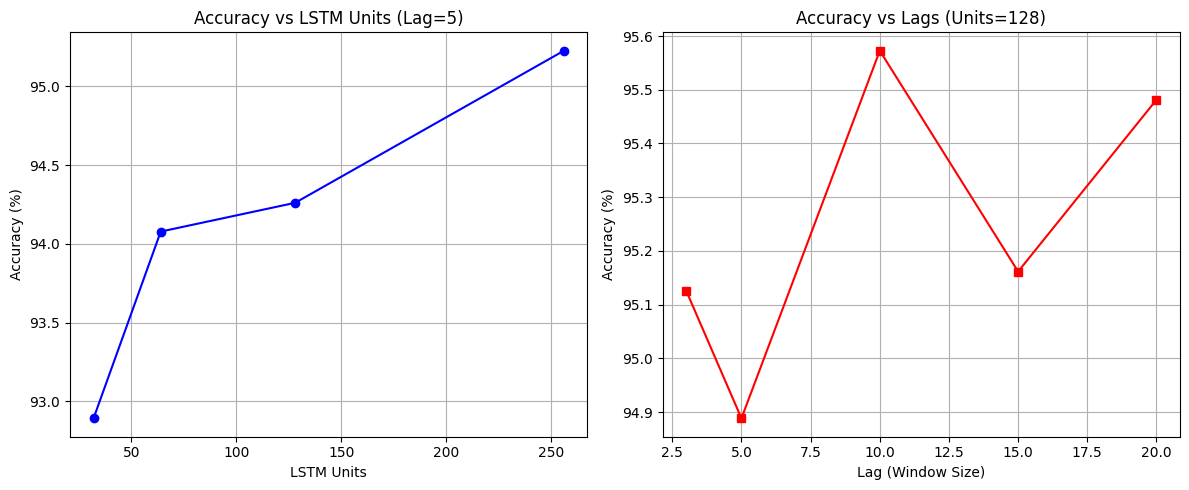

In [18]:
import scipy.io as sio
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn import metrics
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input
import matplotlib.pyplot as plt
import os

# -------------------------------------------------------
# 0. 전역 설정
# -------------------------------------------------------
np.random.seed(42)
tf.random.set_seed(42)

AMP_DIM = 64   # 진폭 차원 (CFR 서브캐리어 수)

# -------------------------------------------------------
# 1. 데이터 로드 및 전처리
# -------------------------------------------------------
mat_path = f"cfr_Fc={freq_str}_v={vel_str}_BW={bw_str}_dt={dt_str}_csi_dataset.mat"

if not os.path.exists(mat_path):
    raise FileNotFoundError(f"❌ 에러: 파일을 찾을 수 없습니다: {mat_path}")

print(f"📂 데이터 파일 로드 중: {mat_path}")
data = sio.loadmat(mat_path)

# [데이터 파싱]
if 'csi' in data:
    csi_amp = data['csi']
elif 'CFR' in data:
    raw_val = data['CFR']
    # 복소수일 경우 여기서 미리 변환할 수도 있지만, 아래에서 통합 처리함
    csi_amp = raw_val
else:
    raise KeyError("파일 내에 'csi' 또는 'CFR' 데이터가 없습니다.")

# [속도 데이터 파싱]
if 'velocities' in data:
    velocity = data['velocities']
else:
    print("⚠️ 경고: 'velocities' 데이터가 없어 0으로 대체합니다.")
    velocity = np.zeros((csi_amp.shape[0], 3))

# 차원 확인 및 보정 (2차원이 아닐 경우)
if csi_amp.ndim > 2:
    csi_amp = csi_amp.reshape(csi_amp.shape[0], -1)

# -------------------------------------------------------
# [핵심 수정 1] 복소수 -> 실수 변환 (Magnitude)
# -------------------------------------------------------
if np.iscomplexobj(csi_amp):
    print("ℹ️ 복소수 데이터 감지 -> 절대값(Magnitude)으로 변환합니다.")
    csi_amp = np.abs(csi_amp)

# -------------------------------------------------------
# [핵심 수정 2] 데이터 길이 맞추기 (Slicing)
# -------------------------------------------------------
min_len = min(csi_amp.shape[0], velocity.shape[0])

if csi_amp.shape[0] != velocity.shape[0]:
    print(f"⚠️ 데이터 길이 불일치! CSI: {csi_amp.shape[0]}, Velocity: {velocity.shape[0]}")
    print(f"   -> {min_len}개로 맞춥니다.")

csi_amp = csi_amp[:min_len]
velocity = velocity[:min_len]

# 데이터 병합: [CFR(64) | Velocity(3)] -> (min_len, 67)
# 이제 csi_amp가 실수형이므로 안전하게 병합됩니다.
combined_data = np.hstack([csi_amp, velocity])

print(f"✅ 데이터 병합 완료. Shape: {combined_data.shape}, Type: {combined_data.dtype}")

# Train/Test 분할
train_size = int(len(combined_data) * 0.9)
train_data = combined_data[:train_size]
test_data  = combined_data[train_size:]

# 스케일링
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train_data)
scaled_test  = scaler.transform(test_data)

# -------------------------------------------------------
# 2. Helper Functions
# -------------------------------------------------------

def create_dataset(dataset, lags, amp_dim):
    X, Y = [], []
    if len(dataset) <= lags:
        return np.array([]), np.array([])
    for i in range(len(dataset) - lags):
        X.append(dataset[i : i + lags, :]) 
        Y.append(dataset[i + lags, :amp_dim]) # 타깃: 진폭만 예측
    return np.array(X), np.array(Y)

def make_amp_scaler(scaler_all, amp_dim=AMP_DIM):
    scaler_amp = MinMaxScaler()
    scaler_amp.n_features_in_ = amp_dim
    if hasattr(scaler_all, 'feature_range'):
        scaler_amp.feature_range = scaler_all.feature_range
    else:
        scaler_amp.feature_range = (0, 1)
        
    if hasattr(scaler_all, 'min_'):
        scaler_amp.min_             = scaler_all.min_[:amp_dim]
        scaler_amp.scale_           = scaler_all.scale_[:amp_dim]
        scaler_amp.data_min_        = scaler_all.data_min_[:amp_dim]
        scaler_amp.data_max_        = scaler_all.data_max_[:amp_dim]
        scaler_amp.data_range_      = scaler_all.data_range_[:amp_dim]
    return scaler_amp

def get_accuracy(model, X, Y, scaler_all, amp_dim=AMP_DIM):
    Y_pred_scaled = model.predict(X, verbose=0)
    
    scaler_amp = make_amp_scaler(scaler_all, amp_dim)
    Y_true = scaler_amp.inverse_transform(Y)
    Y_pred = scaler_amp.inverse_transform(Y_pred_scaled)
    
    mae = metrics.mean_absolute_error(Y_true, Y_pred)
    mean_val = np.mean(np.abs(Y_true)) + 1e-8
    accuracy = (1.0 - mae / mean_val) * 100.0
    return max(0.0, accuracy)

def run_experiment(units, lags, scaled_train, scaled_test, scaler_all, amp_dim=AMP_DIM, epochs=15):
    X_train, Y_train = create_dataset(scaled_train, lags, amp_dim)
    test_extended = np.concatenate((scaled_train[-lags:], scaled_test), axis=0)
    X_test, Y_test = create_dataset(test_extended, lags, amp_dim)
    
    if len(X_train) == 0 or len(X_test) == 0:
        return 0.0
    
    n_features = X_train.shape[2]
    output_dim = Y_train.shape[1]
    
    model = Sequential()
    model.add(Input(shape=(lags, n_features)))
    model.add(LSTM(units))
    model.add(Dense(output_dim))
    model.compile(optimizer='adam', loss='mse')
    
    model.fit(X_train, Y_train, epochs=epochs, batch_size=32, verbose=0, shuffle=False)
    
    return get_accuracy(model, X_test, Y_test, scaler_all, amp_dim)

# =======================================================
# 실험 A: LSTM 유닛 수 변화
# =======================================================
units_list = [32, 64, 128, 256] 
fixed_lag = 5 
acc_units = []

print(f"Experiment A: LSTM Units (Lag={fixed_lag})")
for u in units_list:
    acc = run_experiment(u, fixed_lag, scaled_train, scaled_test, scaler, AMP_DIM, epochs=20)
    acc_units.append(acc)
    print(f"  Units={u:3d} -> Accuracy: {acc:.2f}%")

# =======================================================
# 실험 B: 윈도우 크기(Lag) 변화
# =======================================================
lags_list = [3, 5, 10, 15, 20] 
fixed_units = 128
acc_lags = []

print(f"\nExperiment B: Lags (Units={fixed_units})")
for l in lags_list:
    acc = run_experiment(fixed_units, l, scaled_train, scaled_test, scaler, AMP_DIM, epochs=20)
    acc_lags.append(acc)
    print(f"  Lag={l:2d} -> Accuracy: {acc:.2f}%")

# =======================================================
# 결과 시각화
# =======================================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(units_list, acc_units, 'o-', color='b')
plt.title(f'Accuracy vs LSTM Units (Lag={fixed_lag})')
plt.xlabel('LSTM Units')
plt.ylabel('Accuracy (%)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(lags_list, acc_lags, 's-', color='r')
plt.title(f'Accuracy vs Lags (Units={fixed_units})')
plt.xlabel('Lag (Window Size)')
plt.ylabel('Accuracy (%)')
plt.grid(True)

plt.tight_layout()
plt.show()

📂 데이터 파일 로드 중: cfr_Fc=5.0GHz_v=2.0m_s_BW=20MHz_dt=1.0ms_csi_dataset.mat
✅ 데이터 로드 및 병합 완료. Shape: (999, 67)
Experiment A: LSTM Units (Lag=5)
  Units= 32 -> MAE: 5.72%, RMSE: 7.42%, R2: 0.953
  Units= 64 -> MAE: 5.27%, RMSE: 6.68%, R2: 0.961
  Units=128 -> MAE: 4.59%, RMSE: 5.92%, R2: 0.970
  Units=256 -> MAE: 3.31%, RMSE: 4.29%, R2: 0.984

Experiment B: Lags (Units=128)
  Lag= 3 -> MAE: 4.54%, RMSE: 5.72%, R2: 0.973
  Lag= 5 -> MAE: 4.46%, RMSE: 5.72%, R2: 0.972
  Lag=10 -> MAE: 4.09%, RMSE: 5.23%, R2: 0.978
  Lag=15 -> MAE: 3.53%, RMSE: 4.58%, R2: 0.983
  Lag=20 -> MAE: 3.63%, RMSE: 4.71%, R2: 0.981


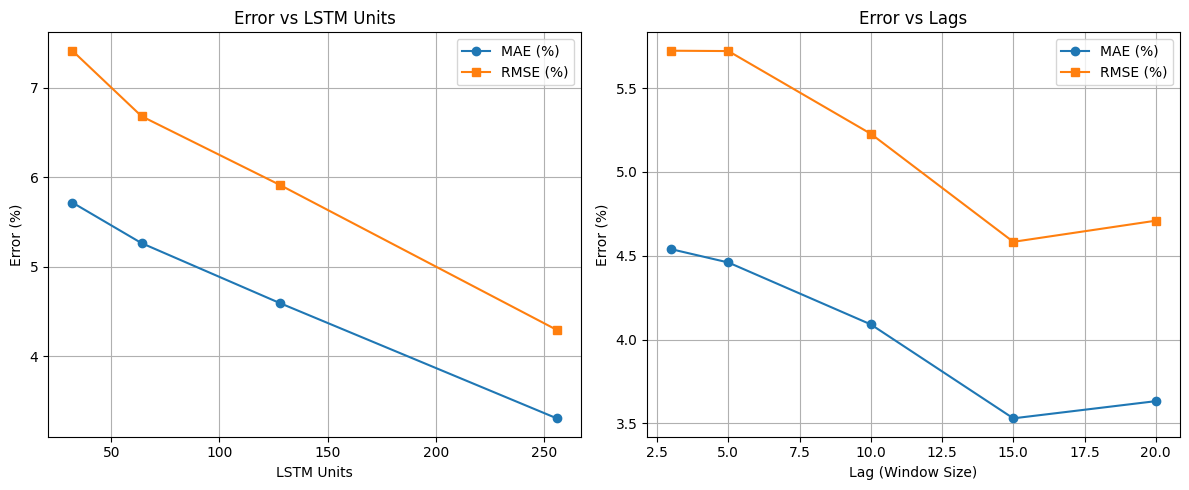

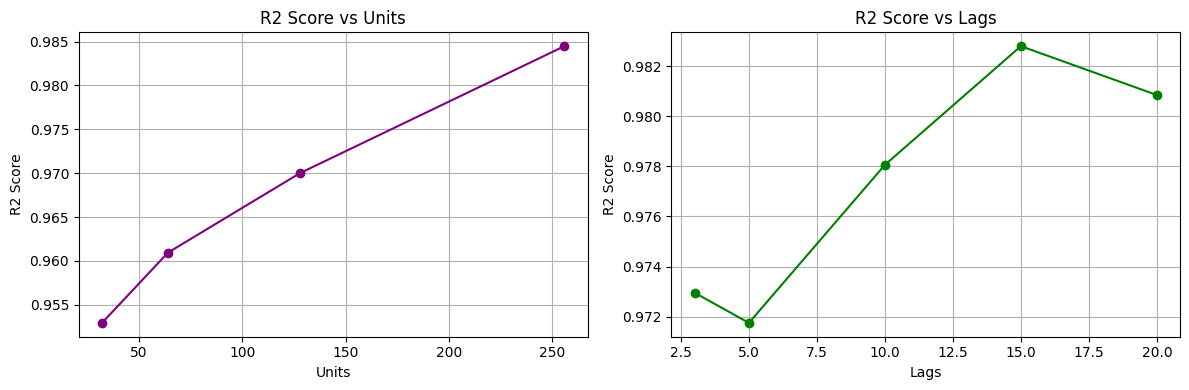

In [19]:
import scipy.io as sio
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn import metrics
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input
import matplotlib.pyplot as plt
import os

# -------------------------------------------------------
# 0. 전역 설정
# -------------------------------------------------------
np.random.seed(42)
tf.random.set_seed(42)

AMP_DIM = 64   # 예측 대상: 64개 서브캐리어 진폭

# -------------------------------------------------------
# 1. 데이터 로드 및 전처리 (Indoor 최적화)
# -------------------------------------------------------
mat_path = f"cfr_Fc={freq_str}_v={vel_str}_BW={bw_str}_dt={dt_str}_csi_dataset.mat"
if not os.path.exists(mat_path):
    raise FileNotFoundError(f"❌ 에러: 파일을 찾을 수 없습니다: {mat_path}")

print(f"📂 데이터 파일 로드 중: {mat_path}")
data = sio.loadmat(mat_path)

# [수정 1] CSI 데이터 로드 및 복소수 처리
# 저장된 데이터는 (Time, Subcarriers) = (1000, 64) 형태의 복소수입니다.
if 'CFR' in data:
    raw_complex = data['CFR']
else:
    raise KeyError("파일 내에 'csi' 데이터가 없습니다.")

# 복소수 -> 진폭(Magnitude) 변환
csi_amp = np.abs(raw_complex)

# 데이터 길이 맞추기 (혹시 모를 불일치 방지)
min_len = min(len(csi_amp), len(velocity))
csi_amp = csi_amp[:min_len]
velocity = velocity[:min_len]

# [수정 3] 데이터 병합: [CFR(64) | Velocity(3)] -> (1000, 67)
combined_data = np.hstack([csi_amp, velocity])

print(f"✅ 데이터 로드 및 병합 완료. Shape: {combined_data.shape}") # (1000, 67)

# Train/Test 분할 (9:1)
train_size = int(len(combined_data) * 0.9)
train_data = combined_data[:train_size]
test_data  = combined_data[train_size:]

# 스케일링
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train_data)
scaled_test  = scaler.transform(test_data)

# -------------------------------------------------------
# 2. Helper Functions (데이터 보존 로직 유지)
# -------------------------------------------------------

def create_dataset(dataset, lags, amp_dim):
    """시계열 윈도우 생성 (Sliding Window)"""
    X, Y = [], []
    if len(dataset) <= lags:
        return np.array([]), np.array([])
        
    for i in range(len(dataset) - lags):
        X.append(dataset[i : i + lags, :]) 
        Y.append(dataset[i + lags, :amp_dim]) # 타깃: 진폭 64개만 예측
    return np.array(X), np.array(Y)

def make_amp_scaler(scaler_all, amp_dim=AMP_DIM):
    """진폭 부분만 복원하기 위한 스케일러 생성"""
    scaler_amp = MinMaxScaler()
    scaler_amp.n_features_in_ = amp_dim
    
    if hasattr(scaler_all, 'feature_range'):
        scaler_amp.feature_range = scaler_all.feature_range
    else:
        scaler_amp.feature_range = (0, 1)

    if hasattr(scaler_all, 'min_'):
        scaler_amp.min_             = scaler_all.min_[:amp_dim]
        scaler_amp.scale_           = scaler_all.scale_[:amp_dim]
        scaler_amp.data_min_        = scaler_all.data_min_[:amp_dim]
        scaler_amp.data_max_        = scaler_all.data_max_[:amp_dim]
        scaler_amp.data_range_      = scaler_all.data_range_[:amp_dim]
    return scaler_amp

def compute_metrics(model, X, Y, scaler_all, amp_dim=AMP_DIM):
    # 1) 예측
    Y_pred_scaled = model.predict(X, verbose=0)
    
    # 2) 역변환 (Original Scale)
    scaler_amp = make_amp_scaler(scaler_all, amp_dim)
    Y_true = scaler_amp.inverse_transform(Y)
    Y_pred = scaler_amp.inverse_transform(Y_pred_scaled)
    
    # 3) 지표 계산
    mae = metrics.mean_absolute_error(Y_true, Y_pred)
    mse = metrics.mean_squared_error(Y_true, Y_pred)
    rmse = np.sqrt(mse)
    r2 = metrics.r2_score(Y_true, Y_pred)
    
    # MAPE 스타일 지표 (평균 대비 오차율 %)
    mean_abs = np.mean(np.abs(Y_true)) + 1e-8
    mae_percent = 100 * mae / mean_abs
    rmse_percent = 100 * rmse / mean_abs
    
    return {
        "mae_percent": mae_percent,
        "rmse_percent": rmse_percent,
        "r2": r2
    }

def run_experiment_metrics(units, lags, scaled_train, scaled_test, scaler_all,
                           amp_dim=AMP_DIM, epochs=30):
    
    # 1. Train 데이터셋 생성
    X_train, Y_train = create_dataset(scaled_train, lags, amp_dim)
    
    # 2. Test 데이터셋 생성 (Train 끝부분 이어붙여서 끊김 방지)
    test_extended = np.concatenate((scaled_train[-lags:], scaled_test), axis=0)
    X_test, Y_test = create_dataset(test_extended, lags, amp_dim)
    
    if len(X_train) == 0 or len(X_test) == 0:
        return {"mae_percent": 0.0, "rmse_percent": 0.0, "r2": 0.0}

    n_features = X_train.shape[2]
    output_dim = Y_train.shape[1]

    # 3. 모델 정의
    model = Sequential()
    model.add(Input(shape=(lags, n_features)))
    model.add(LSTM(units))
    model.add(Dense(output_dim))
    model.compile(optimizer='adam', loss='mse')

    # 4. 학습 (데이터 1000개 -> batch_size 32 적절)
    model.fit(
        X_train, Y_train,
        epochs=epochs,
        batch_size=32,  
        verbose=0,
        shuffle=False
    )

    return compute_metrics(model, X_test, Y_test, scaler_all, amp_dim)

# =======================================================
# 실험 A: LSTM 유닛 수 변화
# =======================================================
units_list = [32, 64, 128, 256] 
fixed_lag = 5 
mae_list = []
rmse_list = []
r2_list_units = []

print(f"Experiment A: LSTM Units (Lag={fixed_lag})")
for u in units_list:
    m = run_experiment_metrics(u, fixed_lag, scaled_train, scaled_test, scaler,
                               amp_dim=AMP_DIM, epochs=30)
    mae_list.append(m["mae_percent"])
    rmse_list.append(m["rmse_percent"])
    r2_list_units.append(m["r2"])
    print(f"  Units={u:3d} -> MAE: {m['mae_percent']:.2f}%, RMSE: {m['rmse_percent']:.2f}%, R2: {m['r2']:.3f}")

# =======================================================
# 실험 B: 윈도우 크기(Lag) 변화
# =======================================================
lags_list = [3, 5, 10, 15, 20] 
fixed_units = 128
mae_lags = []
rmse_lags = []
r2_list_lags = []

print(f"\nExperiment B: Lags (Units={fixed_units})")
for l in lags_list:
    m = run_experiment_metrics(fixed_units, l, scaled_train, scaled_test, scaler,
                               amp_dim=AMP_DIM, epochs=30)
    mae_lags.append(m["mae_percent"])
    rmse_lags.append(m["rmse_percent"])
    r2_list_lags.append(m["r2"])
    print(f"  Lag={l:2d} -> MAE: {m['mae_percent']:.2f}%, RMSE: {m['rmse_percent']:.2f}%, R2: {m['r2']:.3f}")

# =======================================================
# 결과 시각화
# =======================================================
plt.figure(figsize=(12, 5))

# 그래프 1: Units vs 에러
plt.subplot(1, 2, 1)
plt.plot(units_list, mae_list,  marker='o', label='MAE (%)')
plt.plot(units_list, rmse_list, marker='s', label='RMSE (%)')
plt.title('Error vs LSTM Units')
plt.xlabel('LSTM Units')
plt.ylabel('Error (%)')
plt.legend()
plt.grid(True)

# 그래프 2: Lags vs 에러
plt.subplot(1, 2, 2)
plt.plot(lags_list, mae_lags,  marker='o', label='MAE (%)')
plt.plot(lags_list, rmse_lags, marker='s', label='RMSE (%)')
plt.title('Error vs Lags')
plt.xlabel('Lag (Window Size)')
plt.ylabel('Error (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# R2 Score 그래프
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(units_list, r2_list_units, marker='o', color='purple')
plt.title('R2 Score vs Units')
plt.xlabel('Units')
plt.ylabel('R2 Score')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(lags_list, r2_list_lags, marker='o', color='green')
plt.title('R2 Score vs Lags')
plt.xlabel('Lags')
plt.ylabel('R2 Score')
plt.grid(True)

plt.tight_layout()
plt.show()